# EDA — Previsão de Chuva (RainTomorrow)

> **Objetivo:** Análise exploratória do dataset `weatherAUS` para identificar padrões, correlações e features relevantes na previsão de chuva no dia seguinte.

---

## Etapas

| # | Seção | Descrição |
|:---:|:---|:---|
| 1 | **Loading e Visão Geral** | Leitura, dimensões, tipos e visão inicial dos dados |
| 2 | **Qualidade dos Dados** | Análise de nulos e decisões de tratamento |
| 3 | **Tratamento e Corte OOT** | Limpeza, encoding, separação temporal |
| 4 | **Análise Numérica** | Correlações, multicolinearidade e top features |
| 5 | **Análise Categórica** | Testes de significância (Chi² + V de Cramér) |
| 6 | **Análise Temporal** | Sazonalidade e distribuição por mês |
| 7 | **Pipelines de Preprocessing** | Estrutura de tratamento e determinação das pipelines dos modelos para modelagem |

---
## 1.0) Loading e Visão Geral

In [ ]:
%load_ext autoreload
%autoreload 2

In [1]:
# ── Path e sistema ──
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

import os
import warnings

# ── Dados e computação ──
import numpy as np
import pandas as pd

# ── Visualização ──
import matplotlib.pyplot as plt
import seaborn as sns

# ── Utilitários do projeto ──
from utils import (
    analisar_valores_nulos,
    plot_correlacao_alvo,
    analisar_multicolinearidade_pares,
    resumo_estatistico,
    plot_matriz_correlacao,
    plot_nulos_historico,
    plot_analise_temporal,
    plot_grid_distribuicao,
    plot_grid_boxplot_alvo,
    teste_significancia_chi2,
)

# ── Sklearn (usado nas pipelines) ──
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder,
    FunctionTransformer,
)

# ── Configuração ──
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

In [3]:
# Carrega o dataset weatherAUS a partir da pasta data
caminho_arquivo = os.path.join('..', 'data', 'weatherAUS.csv')
df = pd.read_csv(caminho_arquivo)

# Exibe dimensões e primeiras linhas
print(f'Dimensões: {df.shape[0]:,} linhas × {df.shape[1]} colunas\n')
display(df.head())

Dimensões: 145,460 linhas × 23 colunas



,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [4]:
# Exibe informações gerais: tipos, nulos e uso de memória
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null   float64


In [5]:
# Conta colunas numéricas e categóricas
df_numerico = df.select_dtypes(include='number')
df_categorico = df.select_dtypes(include='object')

print(f'Colunas numéricas: {df_numerico.shape[1]}')
print(f'Colunas categóricas: {df_categorico.shape[1]}')

Colunas numéricas: 16
Colunas categóricas: 7


In [6]:
# Estatísticas descritivas das variáveis numéricas
df.describe(include='number')

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [7]:
# Estatísticas descritivas das variáveis categóricas
df.describe(exclude='number')

,Date,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow
count,145460,145460,135134,134894,141232,142199,142193
unique,3436,49,16,16,16,2,2
top,2013-03-01,Canberra,W,N,SE,No,No
freq,49,3436,9915,11758,10838,110319,110316


### 1.1) Classificação das Variáveis

#### Numéricas (14)

| Coluna | Tipo | Valores Únicos | Intervalo |
|:---|:---:|:---:|:---|
| **MinTemp** | float64 | 389 | -8.5 a 33.9 °C |
| **MaxTemp** | float64 | 505 | -4.8 a 48.1 °C |
| **Rainfall** | float64 | 681 | 0.0 a 371.0 mm |
| **Evaporation** | float64 | 358 | 0.0 a 145.0 mm |
| **Sunshine** | float64 | 145 | 0.0 a 14.5 h |
| **WindGustSpeed** | float64 | 67 | 6 a 135 km/h |
| **WindSpeed9am** | float64 | 43 | 0 a 130 km/h |
| **WindSpeed3pm** | float64 | 44 | 0 a 87 km/h |
| **Humidity9am** | float64 | 101 | 0 a 100% |
| **Humidity3pm** | float64 | 101 | 0 a 100% |
| **Pressure9am** | float64 | 546 | 980.5 a 1041.0 hPa |
| **Pressure3pm** | float64 | 549 | 977.1 a 1039.6 hPa |
| **Temp9am** | float64 | 441 | -7.2 a 40.2 °C |
| **Temp3pm** | float64 | 502 | -5.4 a 46.7 °C |

#### Categóricas Nominais (4)

| Coluna | Tipo | Valores Únicos | Mais Frequente |
|:---|:---:|:---:|:---|
| **Location** | str | 49 | Canberra (3436) |
| **WindGustDir** | str | 16 | W (9915) |
| **WindDir9am** | str | 16 | N (11758) |
| **WindDir3pm** | str | 16 | SE (10838) |

#### Categóricas Ordinais (2) — escala de 0 a 9 oitavos de céu

| Coluna | Tipo | Valores Únicos | Intervalo |
|:---|:---:|:---:|:---|
| **Cloud9am** | float64 | 10 | 0 a 9 |
| **Cloud3pm** | float64 | 10 | 0 a 9 |

#### Binárias (2)

| Coluna | Tipo | Valores Únicos | Não | Sim |
|:---|:---:|:---:|:---|:---|
| **RainToday** | str | 2 | ~76% | ~24% |
| **RainTomorrow** | str | 2 | ~76% | ~24% |

> **Date (str):** 3436 datas únicas — período de 2007-11-01 a 2017-06-25

---
## 2.0) Qualidade dos Dados

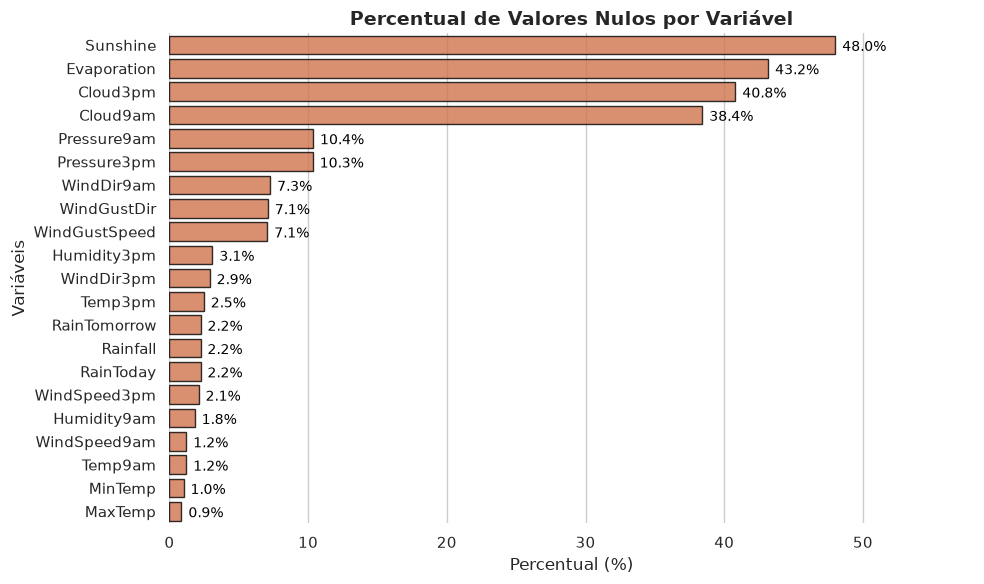

,Total Nulos,Percentual (%),Tipo de Dado
Sunshine,69835,48.009762,float64
Evaporation,62790,43.166506,float64
Cloud3pm,59358,40.807095,float64
Cloud9am,55888,38.421559,float64
Pressure9am,15065,10.356799,float64
Pressure3pm,15028,10.331363,float64
WindDir9am,10566,7.263853,str
WindGustDir,10326,7.098859,str
WindGustSpeed,10263,7.055548,float64
Humidity3pm,4507,3.098446,float64


In [8]:
analisar_valores_nulos(df, plotar=True)

> **Decisão:**
>
> Evitar modelar com features com muitos nulos (top 4: Sunshine, Evaporation, Cloud3pm, Cloud9am).
>
> Não faz sentido preencher nulos com zero — variáveis como temperatura e pressão não podem assumir valor zero arbitrariamente.
>
> Estratégia: **remover linhas sem o target `RainTomorrow`** e fazer **imputação com mediana/moda** nas demais.

---
## 3.0) Tratamento e Corte OOT

>
> **Todos esses tratamentos estão disponíveis no arquivo de src/pipeline.py para a futuro transformação não depender dos notebooks**
>

In [ ]:
# Cópia do dataframe original para tratamento
df_tratado = df.copy()

# (1) Remove linhas sem target
df_tratado = df_tratado.dropna(subset=['RainTomorrow']).copy().reset_index(drop=True)

# (2) Encoding binário dos targets
df_tratado['RainToday'] = df_tratado['RainToday'].map({'Yes': 1, 'No': 0})
df_tratado['RainTomorrow'] = df_tratado['RainTomorrow'].map({'Yes': 1, 'No': 0})

# (3) Conversão de data
df_tratado['Date'] = pd.to_datetime(df_tratado['Date'])

# (4) Coluna auxiliar de mês — usada APENAS para análise de sazonalidade
#     no notebook, NÃO entra como feature do modelo
df_tratado['Month'] = df_tratado['Date'].dt.month

# (5) Remove duplicatas
orig = df_tratado.shape[0]
df_tratado = df_tratado.drop_duplicates()
dps = df_tratado.shape[0]
print(f'Duplicatas removidas: {orig - dps}')

# (6) Ordenação cronológica
df_tratado = df_tratado.sort_values(by='Date').reset_index(drop=True)

# (7) Resumo do corte
linhas_antes = df.shape[0]
linhas_depois = df_tratado.shape[0]
dif = linhas_antes - linhas_depois
print(f'Linhas: {linhas_antes:,} --> {linhas_depois:,} (remocao de {dif} || {100 * dif / linhas_antes:.2f}%)')

> Com quase 150k linhas, remover 2.25% para garantir qualidade do target é uma decisão razoável.
>
> Trabalhando apenas com dados com target evidente.

In [10]:
# Corte DF histórico — somente dados ANTES de 2017
df_historico = df_tratado[df_tratado['Date'] < '2017-01-01'].copy().reset_index(drop=True)

# OOT — Dados de 2017 adiante
df_oot = df_tratado[df_tratado['Date'] >= '2017-01-01'].copy().reset_index(drop=True)

# Exibe resumo dos conjuntos
print('--- Conjunto Histórico (Treino + Teste) ---')
print(f"Periodo: {df_historico['Date'].min():%d/%m/%Y} ate {df_historico['Date'].max():%d/%m/%Y}")
print(f"Linhas:  {df_historico.shape[0]:,} ({df_historico.shape[0] / len(df_tratado) * 100:.1f}%)\n")

print('--- Conjunto OOT (2017) ---')
print(f"Periodo: {df_oot['Date'].min():%d/%m/%Y} ate {df_oot['Date'].max():%d/%m/%Y}")
print(f"Linhas:  {df_oot.shape[0]:,} ({df_oot.shape[0] / len(df_tratado) * 100:.1f}%)\n")

# Compara taxa do target entre os conjuntos
print('--- Taxa do Target (RainTomorrow = 1) ---')
print(f"Historico: {df_historico['RainTomorrow'].mean() * 100:.2f}%")
print(f"OOT:       {df_oot['RainTomorrow'].mean() * 100:.2f}%")

--- Conjunto Histórico (Treino + Teste) ---
Periodo: 01/11/2007 ate 31/12/2016
Linhas:  133,727 (94.0%)

--- Conjunto OOT (2017) ---
Periodo: 01/01/2017 ate 25/06/2017
Linhas:  8,466 (6.0%)

--- Taxa do Target (RainTomorrow = 1) ---
Historico: 22.52%
OOT:       20.82%


> A t**axa do target é semelhante nos conjuntos histórico e OOT**, indicando `possível sazonalidade` nas chuvas.
>
> OOT → 8.466 dados (6%) | Histórico → 133.727 dados (94%)

---
## 4.0) Análise Numérica (df_histórico)

> Análise das features numéricas e sua relação com o target.

In [11]:
# Seleciona apenas as colunas numéricas do histórico
df_numericos_hist = df_historico.select_dtypes(include='number')

### 4.1) Matriz de Correlação

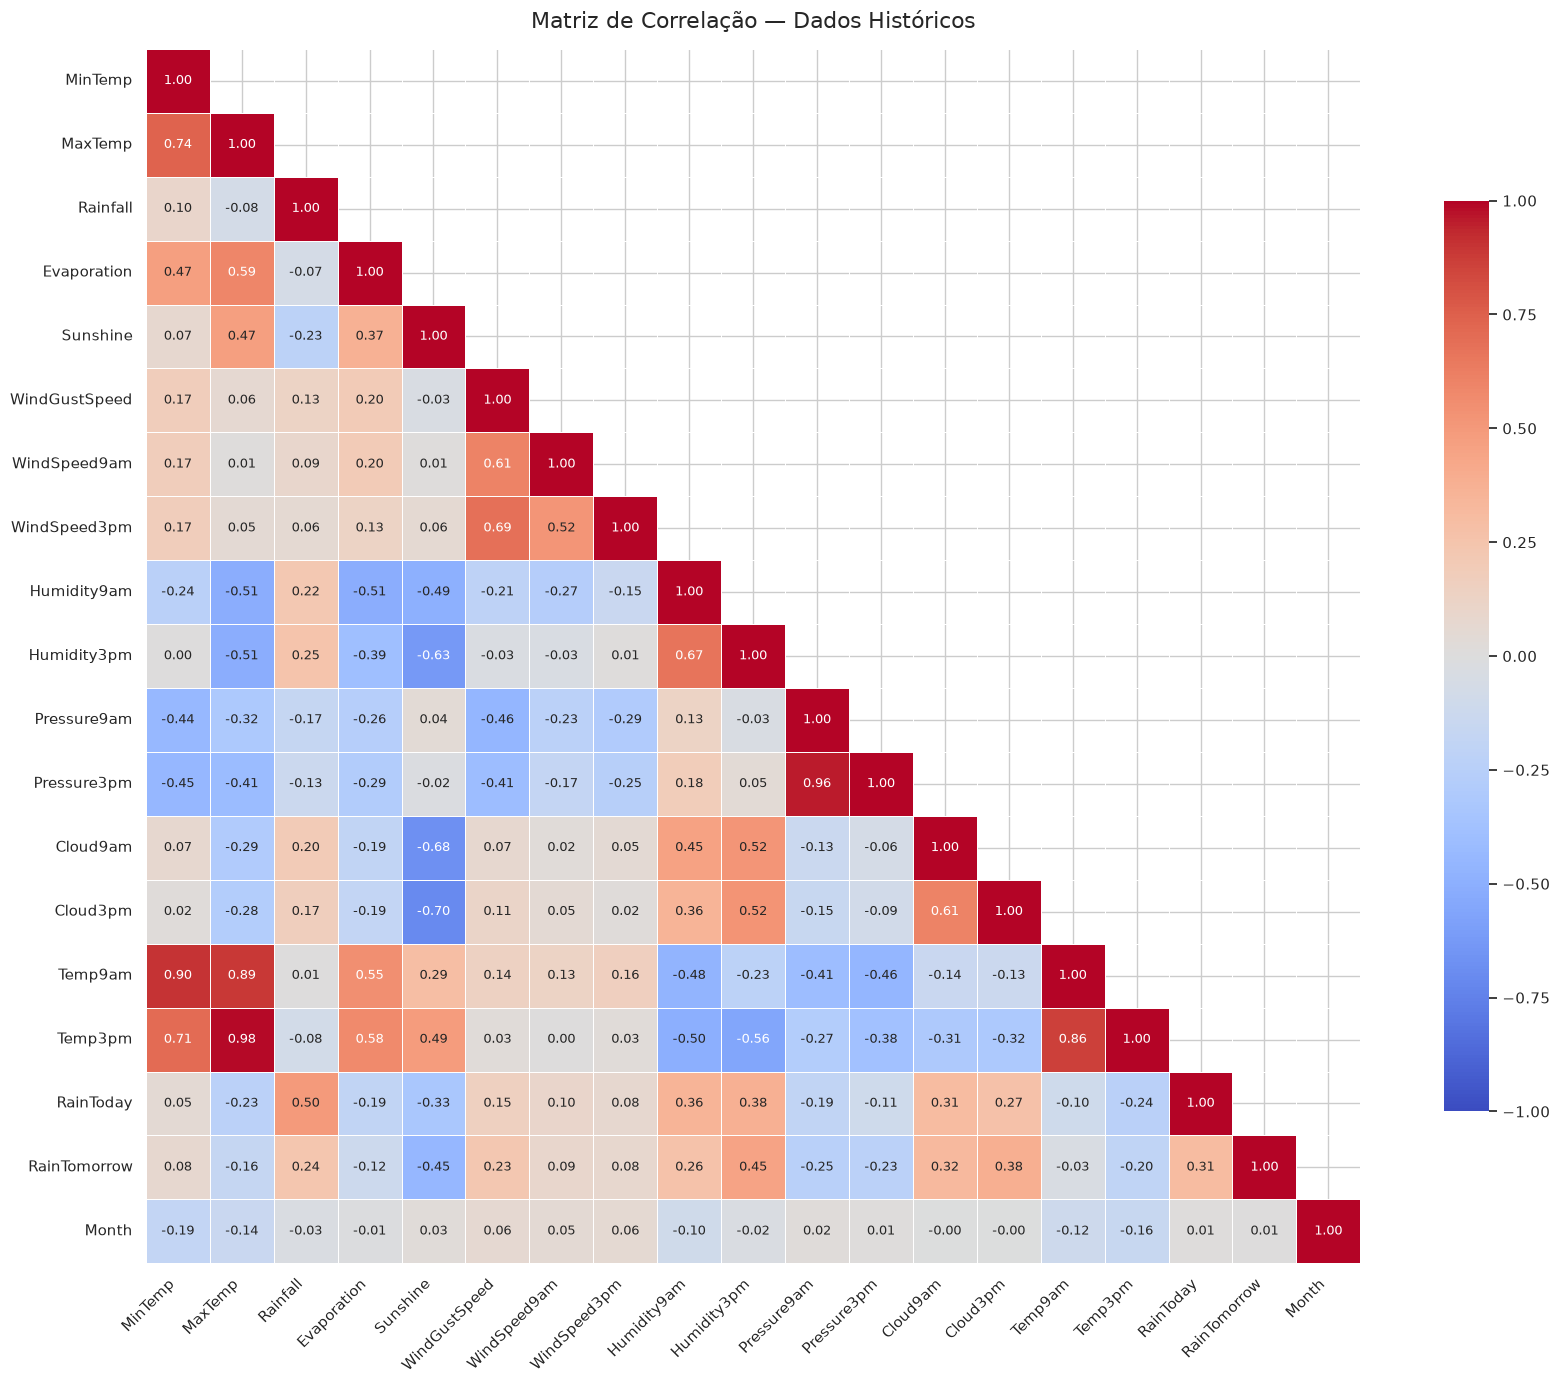

In [12]:
corr = plot_matriz_correlacao(
    df_numericos_hist,
    titulo='Matriz de Correlação — Dados Históricos',
    triangulo=True,
    cmap='coolwarm'
)

### 4.2) Correlação com o Alvo (RainTomorrow)

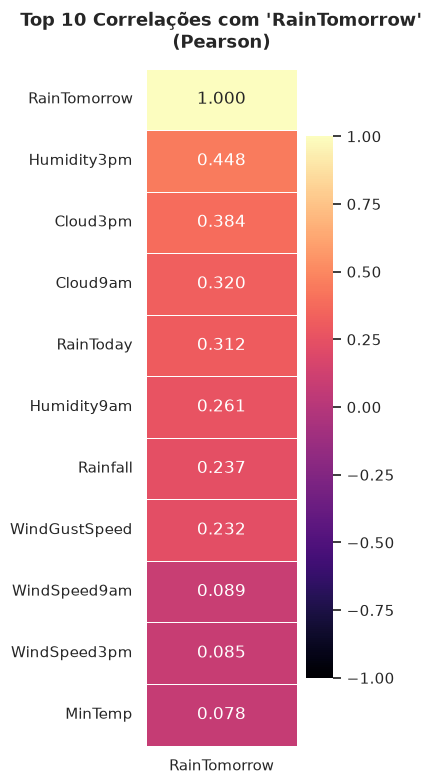

,RainTomorrow
RainTomorrow,1.000000
Humidity3pm,0.447672
Cloud3pm,0.384312
Cloud9am,0.320470
RainToday,0.312072
Humidity9am,0.260911
Rainfall,0.236886
WindGustSpeed,0.231660
WindSpeed9am,0.089117
WindSpeed3pm,0.084620


In [13]:
corr_alvo = plot_correlacao_alvo(df_historico, 'RainTomorrow', cor='magma', metodo='pearson')

display(corr_alvo)

> Features mais impactantes no target:
>
> | Feature | Correlação | Obs |
> |:---|:---:|:---|
> | **Humidity3pm** | +0.448 | |
> | **Cloud3pm** | +0.384 | muitos nulos |
> | **Cloud9am** | +0.320 | muitos nulos |
> | **RainToday** | +0.312 | |
> | **Humidity9am** | +0.261 | |
> | **Rainfall** | +0.237 | |
> | **WindGustSpeed** | +0.232 | |
> | **Pressure3pm** | −0.228 | |
> | **Pressure9am** | −0.248 | |
> | **Sunshine** | −0.451 | muitos nulos |

### 4.3) Multicolinearidade

In [14]:
analisar_multicolinearidade_pares(df_numericos_hist, limite=0.6)

--- Pares com Correlação > 0.6 ---
MaxTemp & Temp3pm: 0.985
Pressure9am & Pressure3pm: 0.961
MinTemp & Temp9am: 0.900
MaxTemp & Temp9am: 0.888
Temp9am & Temp3pm: 0.862
MinTemp & MaxTemp: 0.735
MinTemp & Temp3pm: 0.708
Sunshine & Cloud3pm: 0.704
WindGustSpeed & WindSpeed3pm: 0.686
Sunshine & Cloud9am: 0.677
Humidity9am & Humidity3pm: 0.667
Sunshine & Humidity3pm: 0.629
Cloud9am & Cloud3pm: 0.607
WindGustSpeed & WindSpeed9am: 0.606


> **Muitos pares de features semelhantes apresentam alta correlação**:
>
> Cloud9am & Cloud3pm (0.607), WindGustSpeed & WindSpeed3pm (0.686), Temp9am & Temp3pm (0.862), etc.

In [15]:
# Resumo estatístico das top features selecionadas
top_features = ['Humidity3pm', 'RainToday', 'WindGustSpeed', 'Rainfall','Cloud3pm','Pressure3pm', 'Sunshine']

for var in top_features:
    display(f'--- {var} ---')
    display(resumo_estatistico(df_historico, var, monetario=False))

'--- Humidity3pm ---'

,Métrica,Valor
0,Média,51.46
1,Mediana,52.00
2,Desvio Padrão,20.80
3,Mínimo,0.00
4,1º Quartil (Q1 - 25%),37.00
5,3º Quartil (Q3 - 75%),66.00
6,Intervalo Interquartil (IQR),29.00
7,Máximo,100.00
8,Assimetria (Skewness),0.03
9,Curtose (Kurtosis),-0.50


'--- RainToday ---'

,Métrica,Valor
0,Média,0.22
1,Mediana,0.00
2,Desvio Padrão,0.42
3,Mínimo,0.00
4,1º Quartil (Q1 - 25%),0.00
5,3º Quartil (Q3 - 75%),0.00
6,Intervalo Interquartil (IQR),0.00
7,Máximo,1.00
8,Assimetria (Skewness),1.32
9,Curtose (Kurtosis),-0.25


'--- WindGustSpeed ---'

...

,Métrica,Valor
0,Média,4.49
1,Mediana,5.00
2,Desvio Padrão,2.71
3,Mínimo,0.00
4,1º Quartil (Q1 - 25%),2.00
5,3º Quartil (Q3 - 75%),7.00
6,Intervalo Interquartil (IQR),5.00
7,Máximo,9.00
8,Assimetria (Skewness),-0.22
9,Curtose (Kurtosis),-1.46


'--- Pressure3pm ---'

,Métrica,Valor
0,Média,"1,015.22"
1,Mediana,"1,015.20"
2,Desvio Padrão,7.03
3,Mínimo,977.10
4,1º Quartil (Q1 - 25%),"1,010.40"
5,3º Quartil (Q3 - 75%),"1,020.00"
6,Intervalo Interquartil (IQR),9.60
7,Máximo,"1,039.60"
8,Assimetria (Skewness),-0.05
9,Curtose (Kurtosis),0.16


'--- Sunshine ---'

,Métrica,Valor
0,Média,7.62
1,Mediana,8.50
2,Desvio Padrão,3.78
3,Mínimo,0.00
4,1º Quartil (Q1 - 25%),4.90
5,3º Quartil (Q3 - 75%),10.60
6,Intervalo Interquartil (IQR),5.70
7,Máximo,14.50
8,Assimetria (Skewness),-0.50
9,Curtose (Kurtosis),-0.82


> **Humidity3pm e WindGustSpeed** — Features bem comportadas, leve assimetria à direita, dados bem distribuídos. Valores máximos podem indicar tempestades/períodos de forte chuva.
>
> **RainToday** — Binária, bem distribuída.
>
> **Cloud3pm** — Ordinal (0–9): razoavelmente distribuída, bom poder de explicação, mas com **40% de nulos**.
>
> **Rainfall** — Extremamente assimétrica, mediana zero. Necessita transformação log1p → ln(1+x).
>
> **Sunshine** — Distribuição irregular, média distante da mediana, IQR baixo.

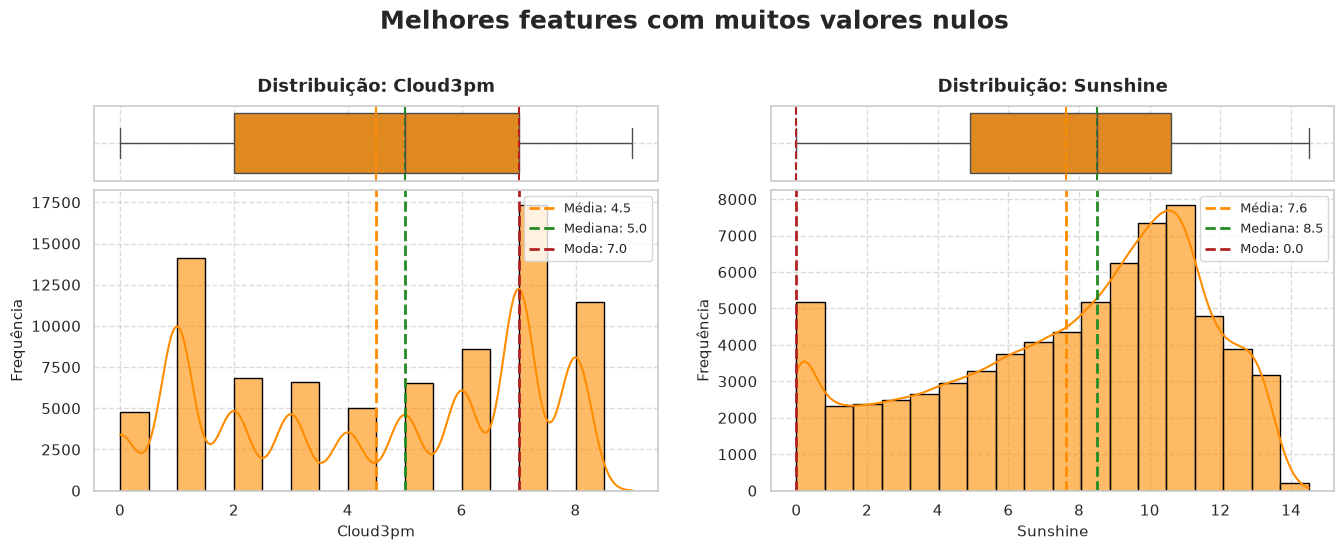

In [16]:
# Distribuição das features com muitos valores nulos
features_nulos = ['Cloud3pm', 'Sunshine']

plot_grid_distribuicao(
    df=df_historico,
    features=features_nulos,
    titulo='Melhores features com muitos valores nulos',
    cor='darkorange',
)

> **Cloud3pm é uma variável ordinal, e se apresenta razoavelvemente bem distribuída: Mediana = 4.5 e Média 5.0, leve assimetria negativa**
>
> Sunshine apresenta uma `considerável cauda a esquerda`

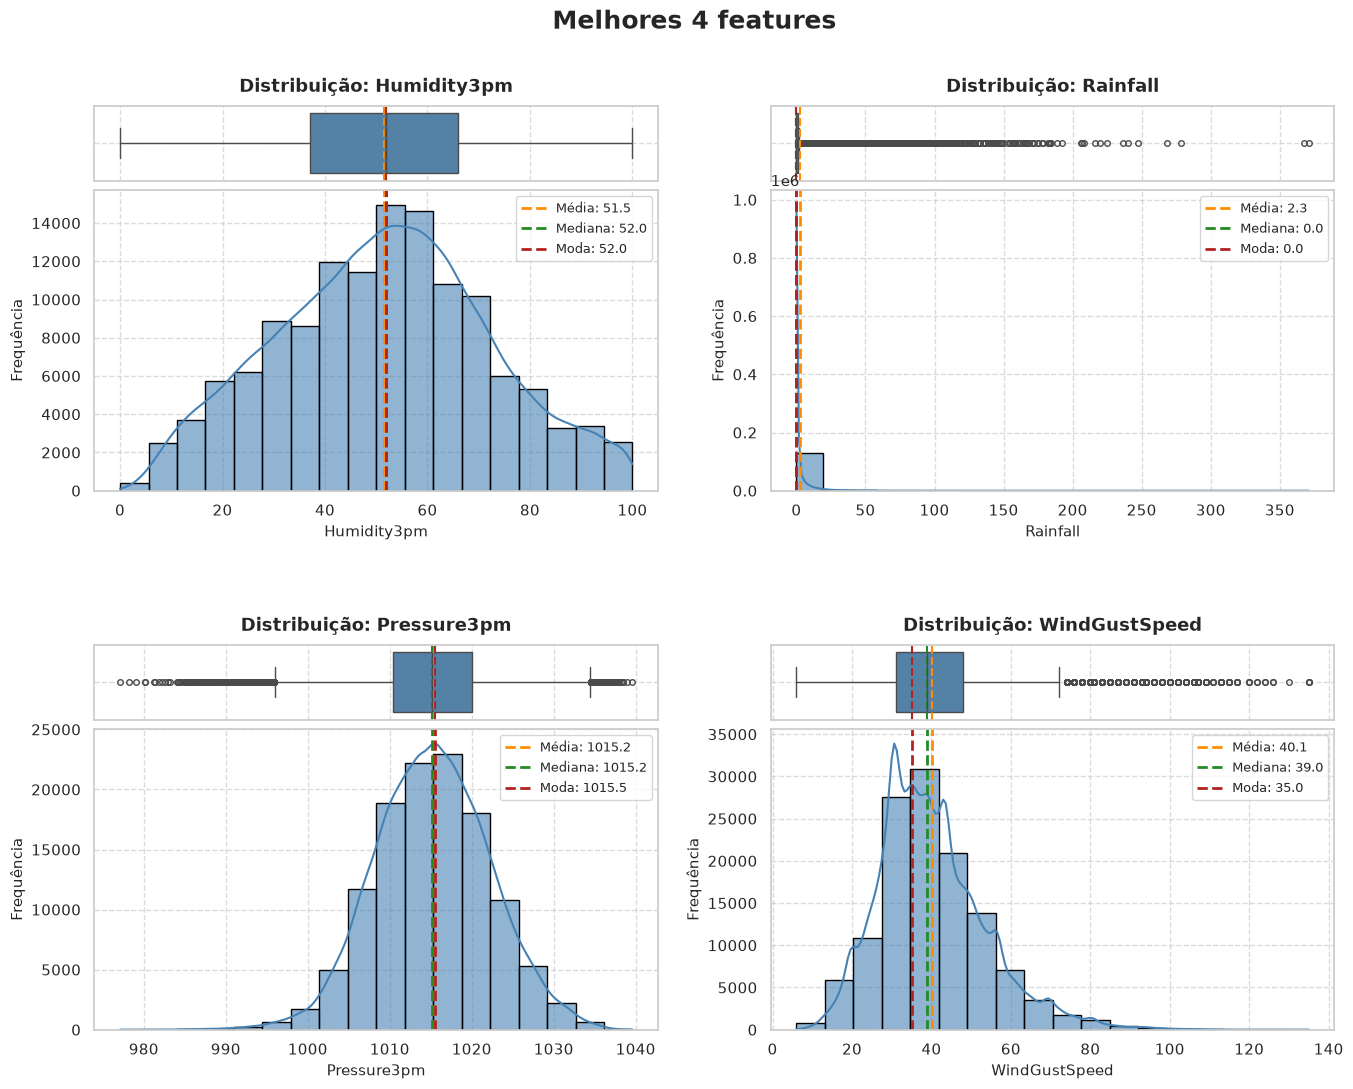

In [17]:
# Distribuição das top 4 features numéricas
features_top4 = ['Humidity3pm', 'Rainfall', 'Pressure3pm', 'WindGustSpeed']

plot_grid_distribuicao(
    df=df_historico,
    features=features_top4,
    titulo='Melhores 4 features',
    cor='steelblue',
)

> **Humidity, Pressure e WindGustSpeed** apresentam-se bem distribuída.
>
> RainFall é um `grave problema na distribuição`, vamos usar **log1p** para buscar suavizar essas rupturas
>
> Sunshine apresenta uma `considerável cauda a esquerda`

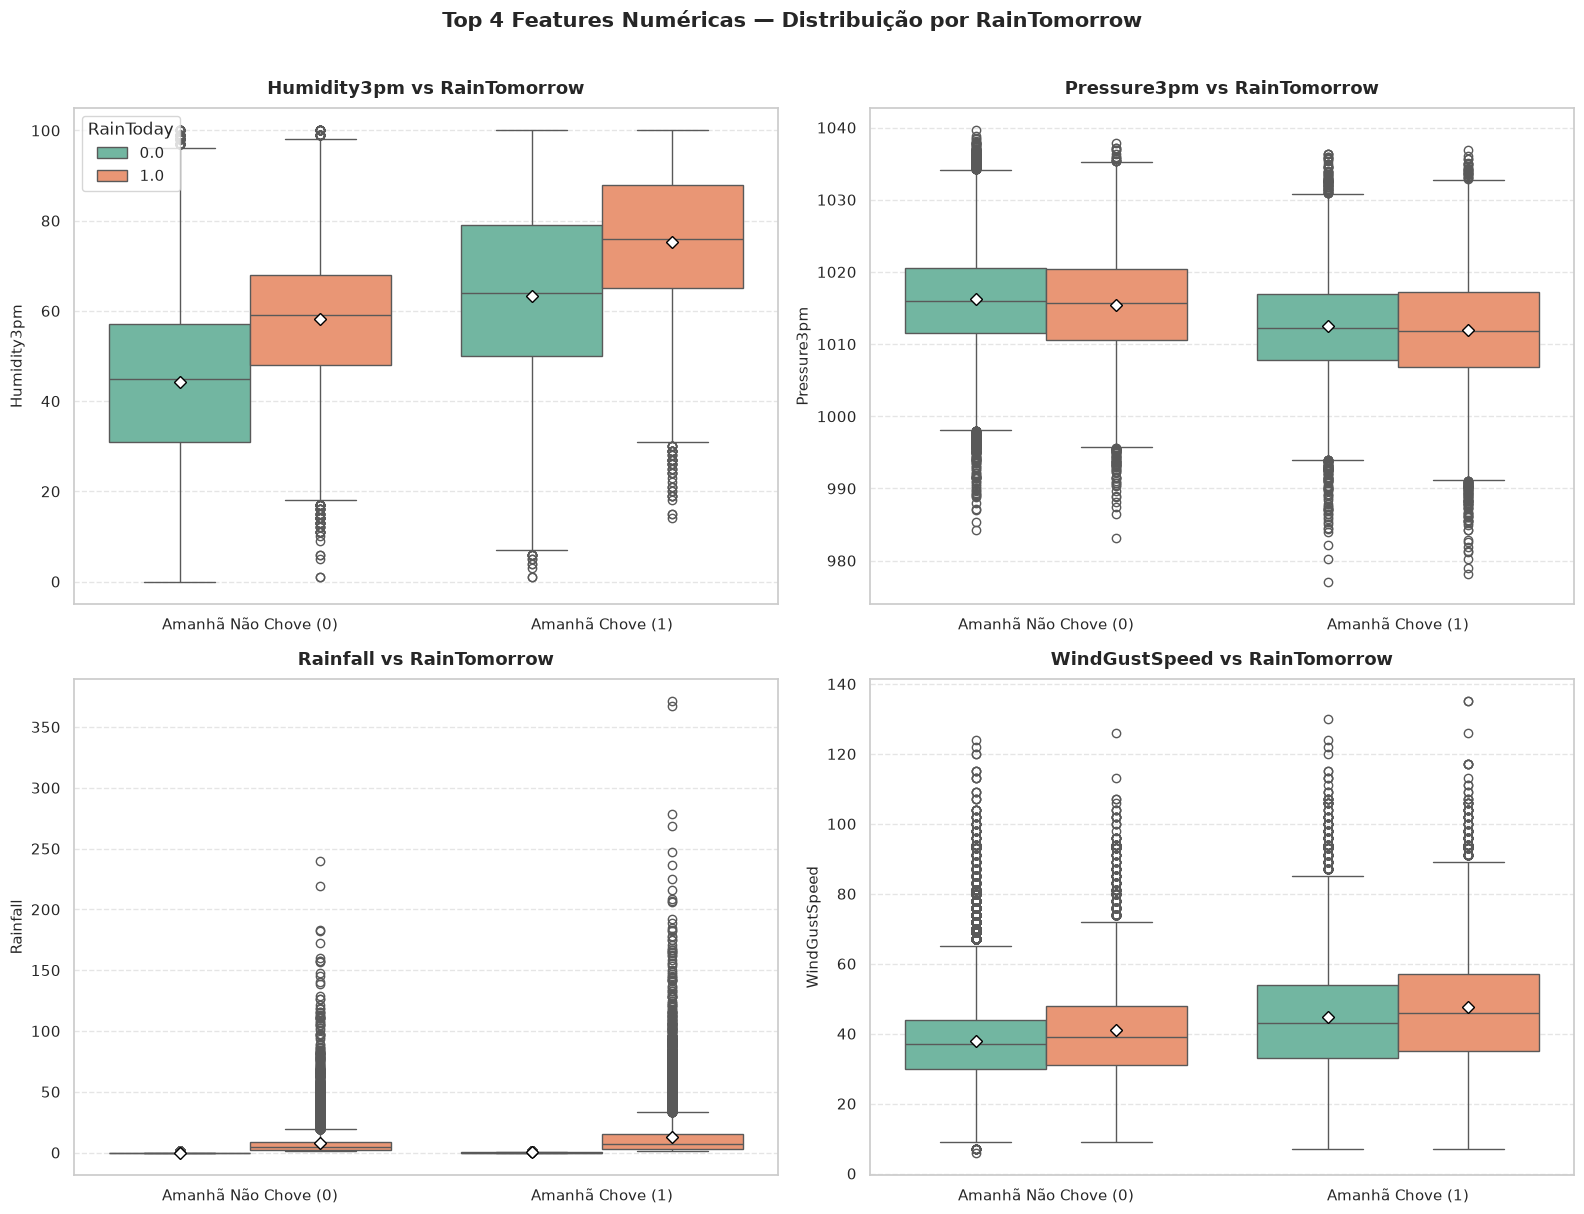

In [18]:
# Boxplots das top 4 features agrupadas pelo target
top_features_numericas = ['Humidity3pm', 'Pressure3pm', 'Rainfall', 'WindGustSpeed']

plot_grid_boxplot_alvo(
    df=df_historico,
    features=top_features_numericas,
    alvo='RainTomorrow',
    hue='RainToday',
    titulo='Top 4 Features Numéricas — Distribuição por RainTomorrow',
    paleta='Set2',
    labels_x=['Amanhã Não Chove (0)', 'Amanhã Chove (1)'],
)

> No dia que antecede as chuvas podemos notar os seguintes padrões:
>
> **Umidade tende a aumentar**
>
> **Pressão tende a abaixar**
>
> **Velocidade dos ventos tende a aumentar**

### 4.5) Nulos no Conjunto Histórico

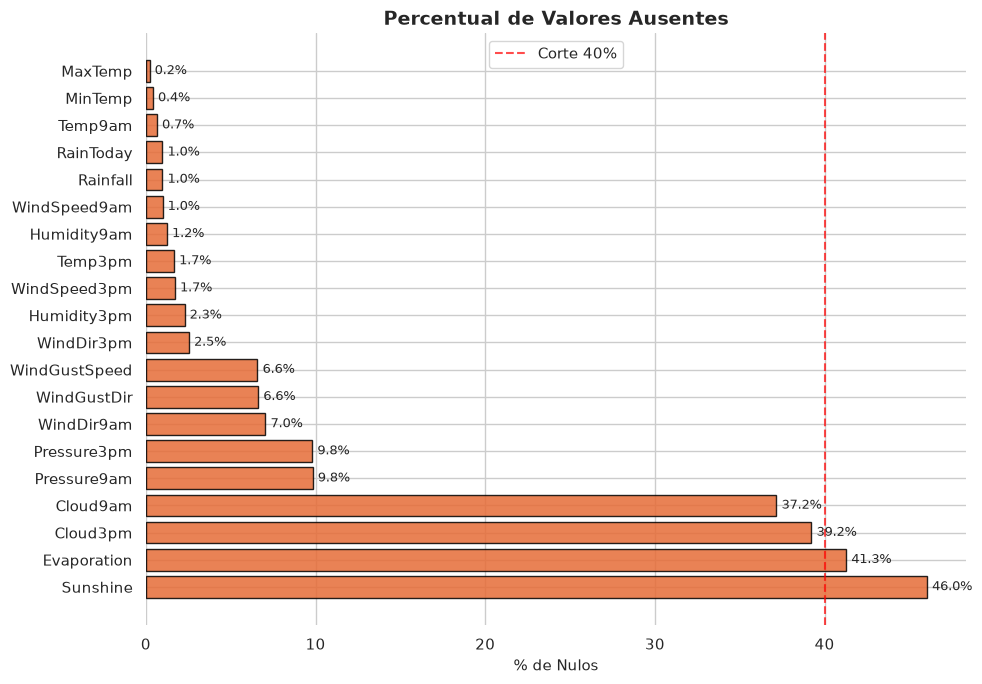

In [19]:
# Percentual de nulos no conjunto histórico (limite de 40%)
nulos_pct = plot_nulos_historico(df_historico, limite=40)

---
## 5.0) Análise Categórica

> Teste **Qui-Quadrado** + **V de Cramér** para medir a força de associação entre variáveis nominais e o target.
>
> Como usaremos algoritmos simples, precisamos reduzir a dimensionalidade
>
> será que as features categóricas são importantes?

In [20]:
# Teste Chi² + V de Cramér para variáveis nominais
colunas_nominais = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']

df_chi2 = teste_significancia_chi2(df_historico, colunas_nominais, alvo='RainTomorrow')
display(df_chi2)

,Feature,Categorias,Chi²,p-valor,V de Cramér
0,Location,49,3305.59,0.0000e+00,0.1572
1,WindDir9am,16,2177.84,0.0000e+00,0.1324
2,WindGustDir,16,1472.52,4.1036e-305,0.1086
3,WindDir3pm,16,1224.60,8.5174e-252,0.0969


> Todas as variáveis categóricas apresentam **p-valor ≈ 0**, rejeitando a hipótese nula.
>
> **Location** possui o maior V de Cramér (0.1572), indicando que a localização geográfica tem a associação mais forte com o target entre as nominais.

---
## 6.0) Análise Temporal

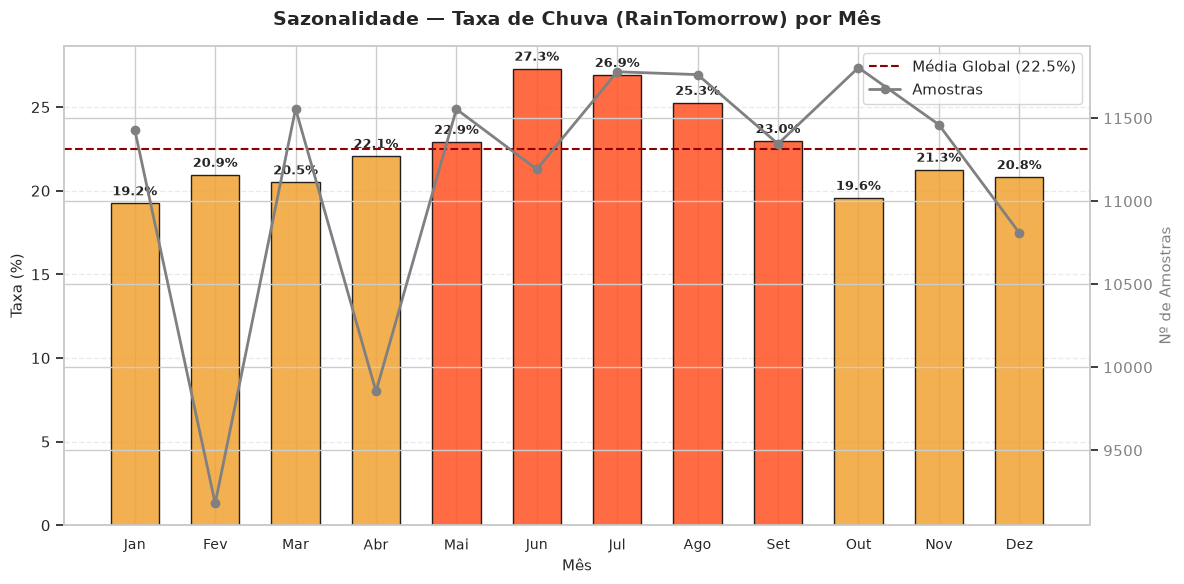

In [21]:
# Análise de sazonalidade da taxa de chuva por mês
taxa_chuva_mes = plot_analise_temporal(
    df_historico,
    titulo='Sazonalidade — Taxa de Chuva (RainTomorrow) por Mês',
    cor_acima='#FF5223',
    cor_abaixo='#F1A233B3',
    cor_media='darkred',
    cor_amostras='grey',
)

> Os meses de **inverno** (Jun–Ago) apresentam as maiores taxas de chuva, enquanto o verão (Dez–Fev) concentra as menores taxas, confirmando sazonalidade clara no target.

---
## 7.0) Pipelines

Buscaremos **4 tipos de pipeline** para avaliar como a complexidade e a qualidade dos dados afetam a Regressão Logística:

* **Enxuta:** Menos features possíveis, buscando reduzir ao máximo a multicolinearidade e a dimensionalidade. O foco é manter apenas os melhores preditores.

5 features numéricas (`Humidity3pm`, `Pressure3pm`, `WindGustSpeed`, `MaxTemp`, `Rainfall`) + 1 categórica (`RainToday`).

* **Intermediária:** Usar mais features, ignorando apenas as piores variáveis que podem explodir a dimensionalidade (como `Location`, que adicionaria 49 colunas via *OneHotEncoding*) ou que possuem redundância extrema.

* **Completa Otimizada:** Usar todas as features possíveis que passaram pela seleção básica, cortando estritamente aquelas com excesso de valores nulos (> 40%).

* **Completa com valores nulos:** Utilizar absolutamente todas as features do *dataset* original, reintroduzindo as colunas com falhas massivas de coleta (como `Sunshine`, `Evaporation` e variáveis `Cloud`).

### 7.1) Definição do Conjunto de Features

In [22]:
# Definição das features por grupo de pipeline
# ==========================================================

# Grupo 1: Enxuto
num_enxuto = ['Humidity3pm', 'Pressure3pm', 'WindGustSpeed', 'MaxTemp']
log_enxuto = ['Rainfall']
cat_enxuto = ['RainToday'] 

# Grupo 2: Intermediário
num_inter = ['Humidity3pm', 'Humidity9am', 'Pressure3pm', 'WindGustSpeed', 'WindSpeed3pm', 'MaxTemp', 'MinTemp']
log_inter = ['Rainfall']
cat_inter = ['RainToday', 'WindGustDir'] 

# Grupo 3: Completo Otimizado
num_comp_otimizada = ['MinTemp', 'MaxTemp', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 
                      'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm']
log_comp_otimizada = ['Rainfall']
cat_nom_comp_otimizada = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

# Grupo 4: Completo (inclui features com muitos nulos)
num_comp_nulos = num_comp_otimizada + ['Evaporation', 'Sunshine']
log_comp_nulos = ['Rainfall']
cat_nom_comp_nulos = cat_nom_comp_otimizada.copy()
cat_ord_comp_nulos = ['Cloud9am', 'Cloud3pm']  # ordinais com ~40% de nulos

### 7.2) Criação das Transformações

> Ajustando as escalas das variáveis com **padronização/normalização**.
>
> Como temos outliers consideráveis, usamos `StandardScaler` nos numéricos para reduzir a influência desses valores.
>
> **Imputer de nulos** → `mediana` para numéricos e `moda` para categóricos.
>
> **One-Hot Encoding** para as categóricas nominais.
>
> **Ordinal Encoding** para as ordinais (Ex = Cloud3pm).
>
>
> A pipeline completa completa será armazenada no arquivo `/src/pipeline.py`

In [23]:
# Criação dos transformers para cada tipo de variável
# ==========================================================

# Pipeline Numérica (padrão para outliers moderados)
num_robust_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline Numérica Logarítmica (para Rainfall — cauda longa extrema)
num_log_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0.0)),
    ('log_transform', FunctionTransformer(np.log1p, validate=False)),
    ('scaler', StandardScaler())
])

# Pipeline Categórica Nominal
cat_nominal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# Pipeline Categórica Ordinal (para Cloud9am/Cloud3pm)
cat_ordinal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('encoder', OrdinalEncoder(categories=[[0,1,2,3,4,5,6,7,8,9], [0,1,2,3,4,5,6,7,8,9]], 
                               handle_unknown='use_encoded_value', unknown_value=-1))
])

### 7.3) Criação das Pipelines

In [24]:
# Montagem das 4 pipelines completas de pré-processamento
# ==========================================================

# Pipeline Enxuta
preprocessor_enxuto = ColumnTransformer([
    ('num_robust', num_robust_pipe, num_enxuto),
    ('num_log', num_log_pipe, log_enxuto),
    ('cat_nom', cat_nominal_pipe, cat_enxuto)
], remainder='drop')

# Pipeline Intermediária
preprocessor_intermediario = ColumnTransformer([
    ('num_robust', num_robust_pipe, num_inter),
    ('num_log', num_log_pipe, log_inter),
    ('cat_nom', cat_nominal_pipe, cat_inter)
], remainder='drop')

# Pipeline Completa Otimizada
preprocessor_completo_otimizado = ColumnTransformer([
    ('num_robust', num_robust_pipe, num_comp_otimizada),
    ('num_log', num_log_pipe, log_comp_otimizada),
    ('cat_nom', cat_nominal_pipe, cat_nom_comp_otimizada)
], remainder='drop')

# Pipeline Completa com Valores Nulos
preprocessor_completo_nulos = ColumnTransformer([
    ('num_robust', num_robust_pipe, num_comp_nulos),
    ('num_log', num_log_pipe, log_comp_nulos),
    ('cat_nom', cat_nominal_pipe, cat_nom_comp_nulos),
    ('cat_ord', cat_ordinal_pipe, cat_ord_comp_nulos)
], remainder='drop')